# Notebook 4: SoT on Other AR Models

The SoTo search framework is designed to be model-agnostic — any autoregressive image model that implements the `BaseARPrior` interface can plug in and use the same search algorithms and verifiers.

This notebook demonstrates SoT on two additional AR models:

1. **Janus-Pro 7B** (DeepSeek) — multimodal AR model with VQ-VAE tokenizer.
2. **Infinity 2B** (FoundationVision) — multi-scale AR model with BSQ-VAE, scale-by-scale generation.

For each model we run: **Direct AR → Best-of-N → Beam Search → Lookahead**, using ImageReward as the verifier and the same prompt as Notebook 1.

Optional dependency note:

```bash
# Janus support
pip install -e '.[janus]'

# Infinity support
pip install -e '.[infinity]'
```

Install `.[janus]` to run the Janus-Pro examples in this notebook, and install `.[infinity]` to run the Infinity examples.


In [1]:
import warnings
import logging
import io
import contextlib

# Suppress warnings/logs before importing third-party packages
warnings.filterwarnings("ignore")
logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("l3m").setLevel(logging.ERROR)    # suppress MoE import message

import torch
import transformers
transformers.utils.logging.set_verbosity_error()
logging.getLogger("soto").setLevel(logging.INFO)     # keep soto model loading / search progress

# Wrap soto imports to suppress print() noise from third-party packages (e.g. janus)
with contextlib.redirect_stdout(io.StringIO()):
    from soto.ar_priors.base import ARPriorFactory
    from soto.verifiers.base import VerifierFactory
    from soto.search_algorithms.base import SearchAlgorithmFactory
    from soto.utils.viz import show_images, show_rows

FIXED_SEED = 0
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

PROMPT = "A painting of a red house with exactly three windows,\
a tall pine tree on one side and a large leafy tree on the other,\
under a bright blue sky with fluffy white clouds."

print(f'Prompt: "{PROMPT}"')

Using device: cuda:0
Prompt: "A painting of a red house with exactly three windows,a tall pine tree on one side and a large leafy tree on the other,under a bright blue sky with fluffy white clouds."


---
## 1. Janus-Pro 7B

**[Janus-Pro](https://github.com/deepseek-ai/Janus)** is amultimodal AR model from DeepSeek that unifies visual understanding and generation. It generates images as a flat sequence of **576 tokens** at 384×384 using a VQ-VAE codebook (16,384 codes).


In [2]:
janus_pro = ARPriorFactory.create("janus_pro", {
    "model_version": "deepseek-ai/Janus-Pro-7B",
    "cfg_factor": 5.0,
    "temperature": 1.0,
}, device=device)

verifier = VerifierFactory.create("image_reward", device=device)
print("Janus-Pro 7B loaded  |  ImageReward verifier loaded")

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.29it/s]


Janus-Pro 7B loaded  |  ImageReward verifier loaded


### 1.1 Model Setup and Direct AR Generation

Direct AR score: 0.216


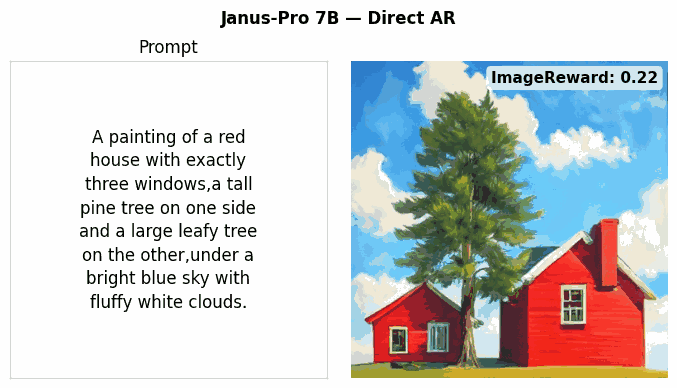

In [3]:
# Direct AR generation — generate all 576 tokens without search.
tokens, _ = janus_pro.generate_next_tokens(
    PROMPT,
    torch.empty(1, 0, dtype=torch.long, device=device),
    num_new_tokens=janus_pro.get_max_tokens(),
)
janus_direct_images = janus_pro.decode_tokens(tokens)

janus_direct_score = verifier.score(janus_direct_images, PROMPT)[0]
print(f"Direct AR score: {float(janus_direct_score):.3f}")

show_images(
    janus_direct_images,
    overlay_labels=[float(janus_direct_score)],
    overlay_prefix="ImageReward",
    main_title="Janus-Pro 7B — Direct AR",
    prompt=PROMPT,
)

### 1.2 Best-of-N

Best-of-10 top scores: 0.792


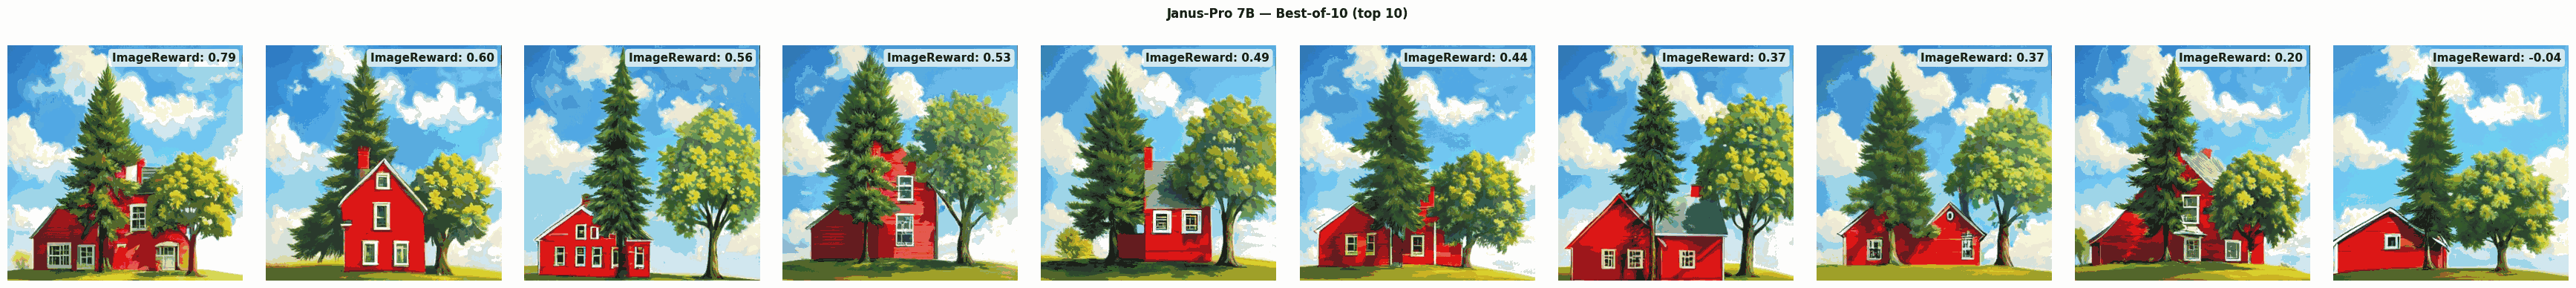

In [4]:
N_SAMPLES = 10
SAMPLES_TO_SHOW = 10

janus_bon_result = SearchAlgorithmFactory.create(
    "best_of_n", ar_prior=janus_pro, verifier=verifier,
    config={"n_samples": N_SAMPLES, "batch_size": 50},
).search(PROMPT, num_results=SAMPLES_TO_SHOW, seed=FIXED_SEED)
print(f"Best-of-{N_SAMPLES} top scores: {float(janus_bon_result.scores[0]):.3f}")

show_images(
    janus_bon_result.images,
    overlay_labels=list(janus_bon_result.scores),
    overlay_prefix="ImageReward",
    ncols=10,
    main_title=f"Janus-Pro 7B — Best-of-{N_SAMPLES} (top {SAMPLES_TO_SHOW})",
)

### 1.3 Beam Search

Step 9/9: 100%|██████████| 9/9 [00:57<00:00,  6.42s/step, score=0.697, tokens=576] 


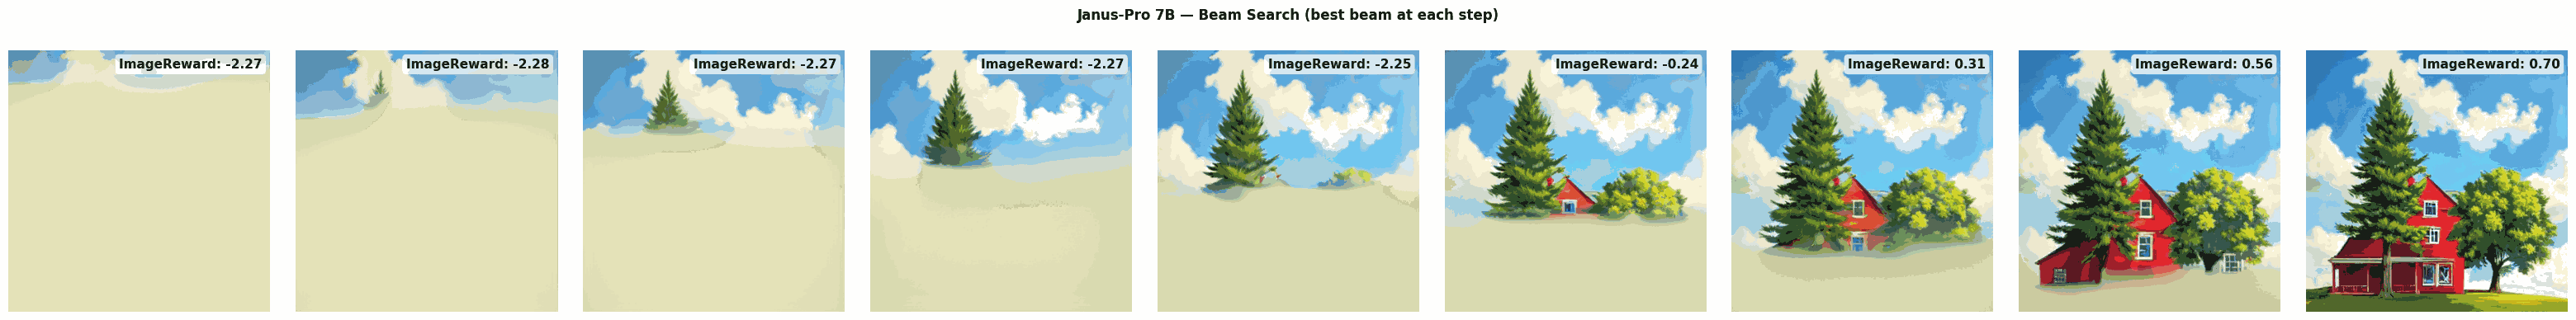

In [5]:
# Takes around 1 min to finish on a h100.
JANUS_BEAM_CFG = {
    "beam_width": 5,            # beams kept between steps
    "candidates_per_beam": 10,  # candidates branched from each beam per step
    "token_schedule": "linear", # evenly spaced steps across the full sequence
    "max_steps": 9,             # total search steps
    "tokens_per_step": 64,      # tokens advanced per step (9 × 64 = 576 total)
}

janus_beam_result = SearchAlgorithmFactory.create(
    "beam", ar_prior=janus_pro, verifier=verifier, config=JANUS_BEAM_CFG,
).search(PROMPT, seed=FIXED_SEED)

show_images(
    janus_beam_result.step_images,
    overlay_labels=list(janus_beam_result.step_scores),
    overlay_prefix="ImageReward",
    main_title="Janus-Pro 7B — Beam Search (best beam at each step)",
    ncols=9,
)

### 1.4 Lookahead Search

Step 9/9: 100%|██████████| 9/9 [02:41<00:00, 17.99s/step, score=1.234, tokens=576]


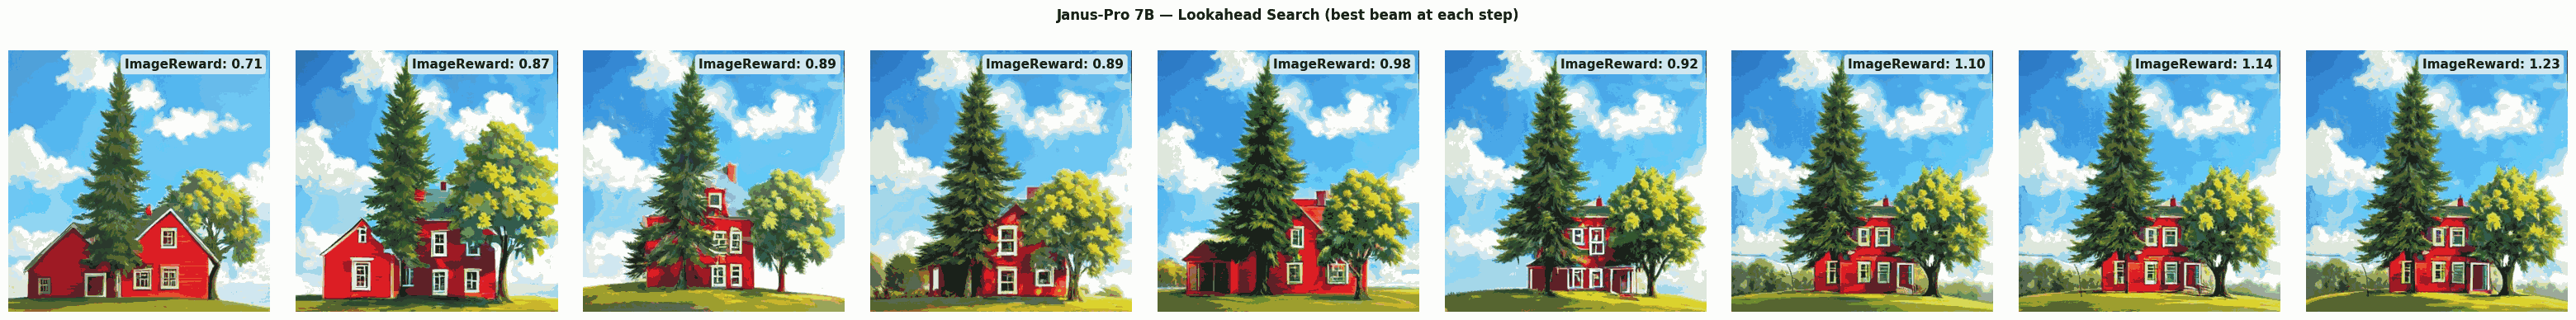

In [6]:
# Takes around 3min to finish on a h100.
JANUS_LA_CFG = {
    "lookahead_number": -1,     # extend to end of sequence before scoring; set to e.g. 64 for partial lookahead
    "beam_width": 5,            # beams kept between steps
    "candidates_per_beam": 10,  # candidates branched from each beam per step
    "token_schedule": "linear", # evenly spaced steps across the full sequence
    "max_steps": 9,             # total search steps
    "tokens_per_step": 64,      # tokens advanced per step (9 × 64 = 576 total)
}

janus_la_result = SearchAlgorithmFactory.create(
    "lookahead", ar_prior=janus_pro, verifier=verifier, config=JANUS_LA_CFG,
).search(PROMPT, seed=FIXED_SEED)

show_images(
    janus_la_result.step_images,
    overlay_labels=list(janus_la_result.step_scores),
    overlay_prefix="ImageReward",
    main_title="Janus-Pro 7B — Lookahead Search (best beam at each step)",
    ncols=9,
)

### 1.5 Summary

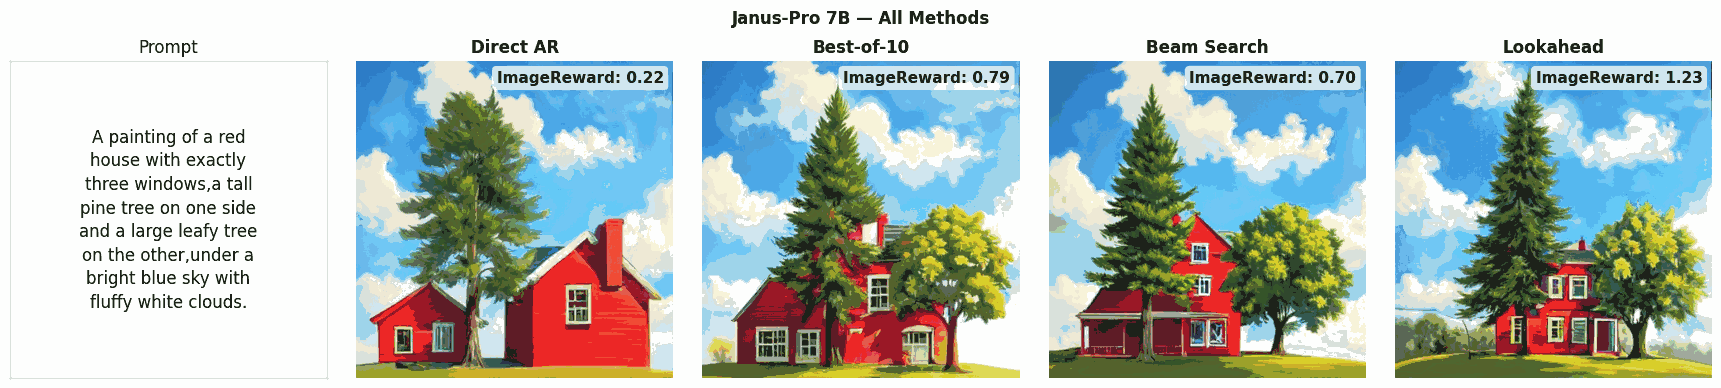

In [7]:
# Summary: compare all four methods on Janus-Pro 7B.
show_images(
    [
        janus_direct_images[0],
        janus_bon_result.images[0],
        janus_beam_result.step_images[-1],
        janus_la_result.step_images[-1],
    ],
    titles=["Direct AR", f"Best-of-{N_SAMPLES}", "Beam Search", "Lookahead"],
    overlay_labels=[
        float(janus_direct_score),
        float(janus_bon_result.scores[0]),
        float(janus_beam_result.step_scores[-1]),
        float(janus_la_result.step_scores[-1]),
    ],
    overlay_prefix="ImageReward",
    prompt=PROMPT,
    main_title="Janus-Pro 7B — All Methods",
)

In [8]:
# clean the model and cache to save memory for later experiments.
del janus_pro
torch.cuda.empty_cache()

---
## 2. Infinity 2B

**[Infinity](https://github.com/FoundationVision/Infinity)** is a multi-scale AR model from FoundationVision that generates images progressively from coarse to fine using a **BSQ-VAE** (binary scalar quantization) tokenizer. 

Key differences from FlexTok and Janus:
- Generation proceeds **scale-by-scale** — each scale adds spatial resolution
- The token schedule aligns naturally with scale boundaries (13 scales total)
- Early scales (1–4) tend to carry less visual information; setting `token_schedule=[5,6,...,13]` skips them and starts search at a later scale
- Supports variable output resolution

In [9]:
infinity_prior = ARPriorFactory.create("infinity", device=device)
infinity_prior.set_seed(FIXED_SEED)
print("Infinity 2B loaded!")

verifier = VerifierFactory.create("image_reward", device=device)
print("ImageReward verifier loaded")

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 20.61it/s]


self.codebook_dim: 32, self.add_lvl_embeding_only_first_block: 1,             self.use_bit_label: 1, self.rope2d_each_sa_layer: 1, self.rope2d_normalized_by_hw: 2
self.num_blocks_in_a_chunk=4, depth=32, block_chunks=8

[constructor]  ==== customized_flash_attn=False (using_flash=0/32), fused_mlp=False (fused_mlp=0/32) ==== 
    [Infinity config ] embed_dim=2048, num_heads=16, depth=32, mlp_ratio=4, swiglu=False num_blocks_in_a_chunk=4
    [drop ratios] drop_rate=0.0, drop_path_rate=0.1 (tensor([0.0000, 0.0032, 0.0065, 0.0097, 0.0129, 0.0161, 0.0194, 0.0226, 0.0258,
        0.0290, 0.0323, 0.0355, 0.0387, 0.0419, 0.0452, 0.0484, 0.0516, 0.0548,
        0.0581, 0.0613, 0.0645, 0.0677, 0.0710, 0.0742, 0.0774, 0.0806, 0.0839,
        0.0871, 0.0903, 0.0935, 0.0968, 0.1000]))

Infinity 2B loaded!
ImageReward verifier loaded


### 2.1 Model Setup and Direct AR Generation

Direct AR score: 0.844


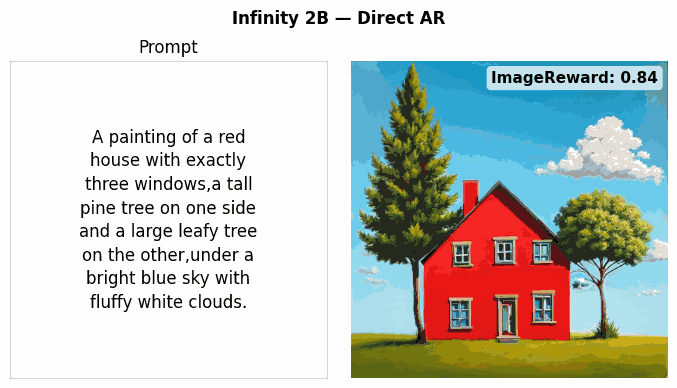

In [10]:
# Direct AR generation — generate all scales without search.
tokens, _ = infinity_prior.generate_next_tokens(
    PROMPT,
    torch.empty(1, 0, dtype=torch.long, device=device),
    num_new_tokens=infinity_prior.get_max_tokens(),
)
inf_direct_images = infinity_prior.decode_tokens(tokens)

inf_direct_score = verifier.score(inf_direct_images, PROMPT)[0]
print(f"Direct AR score: {float(inf_direct_score):.3f}")

show_images(
    inf_direct_images,
    overlay_labels=[float(inf_direct_score)],
    overlay_prefix="ImageReward",
    main_title="Infinity 2B — Direct AR",
    prompt=PROMPT,
)

### 2.2 Best-of-N

Best-of-10 top scores: 0.844


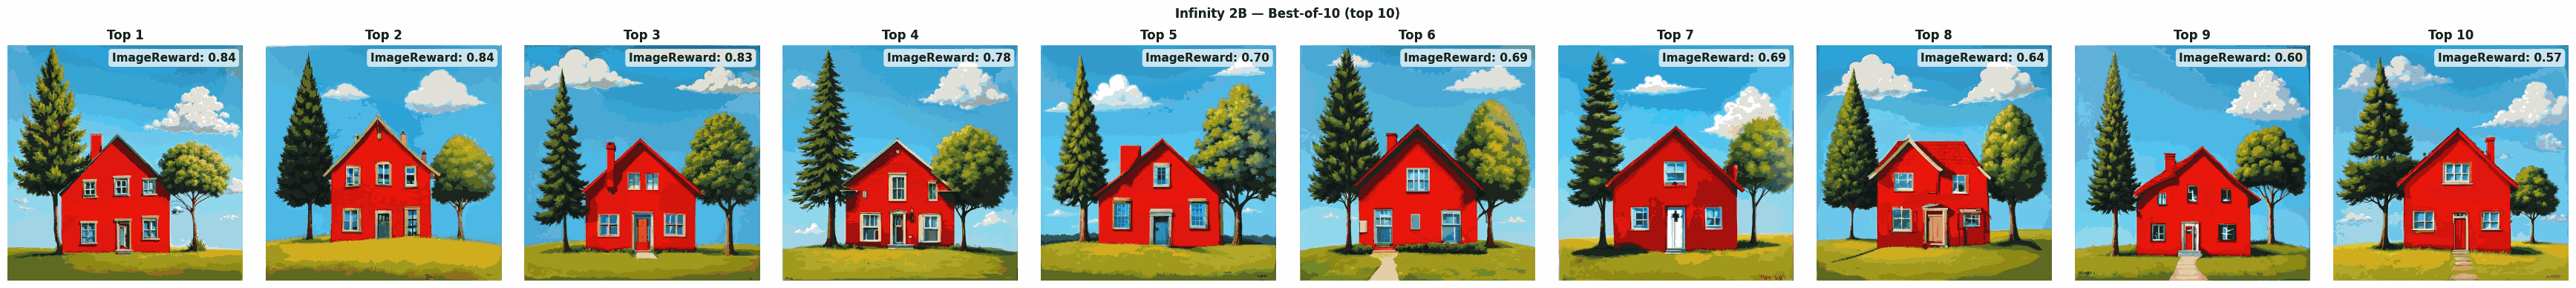

In [11]:
N_SAMPLES = 10
SAMPLES_TO_SHOW = 10
inf_bon_result = SearchAlgorithmFactory.create(
    "best_of_n", ar_prior=infinity_prior, verifier=verifier,
    config={"n_samples": N_SAMPLES, "batch_size": 1},  # Infinity does not support batch_size > 1
).search(PROMPT, num_results=SAMPLES_TO_SHOW, seed=FIXED_SEED)
print(f"Best-of-{N_SAMPLES} top scores: {float(inf_bon_result.scores[0]):.3f}")

show_images(
    inf_bon_result.images,
    titles=[f"Top {s+1}" for s in range(SAMPLES_TO_SHOW)],
    overlay_labels=list(inf_bon_result.scores),
    overlay_prefix="ImageReward",
    ncols=SAMPLES_TO_SHOW,
    main_title=f"Infinity 2B — Best-of-{N_SAMPLES} (top {SAMPLES_TO_SHOW})",
)

### 2.3 Beam Search

Step 13/13: 100%|██████████| 13/13 [02:30<00:00, 11.55s/step, score=1.025, tokens=10521]


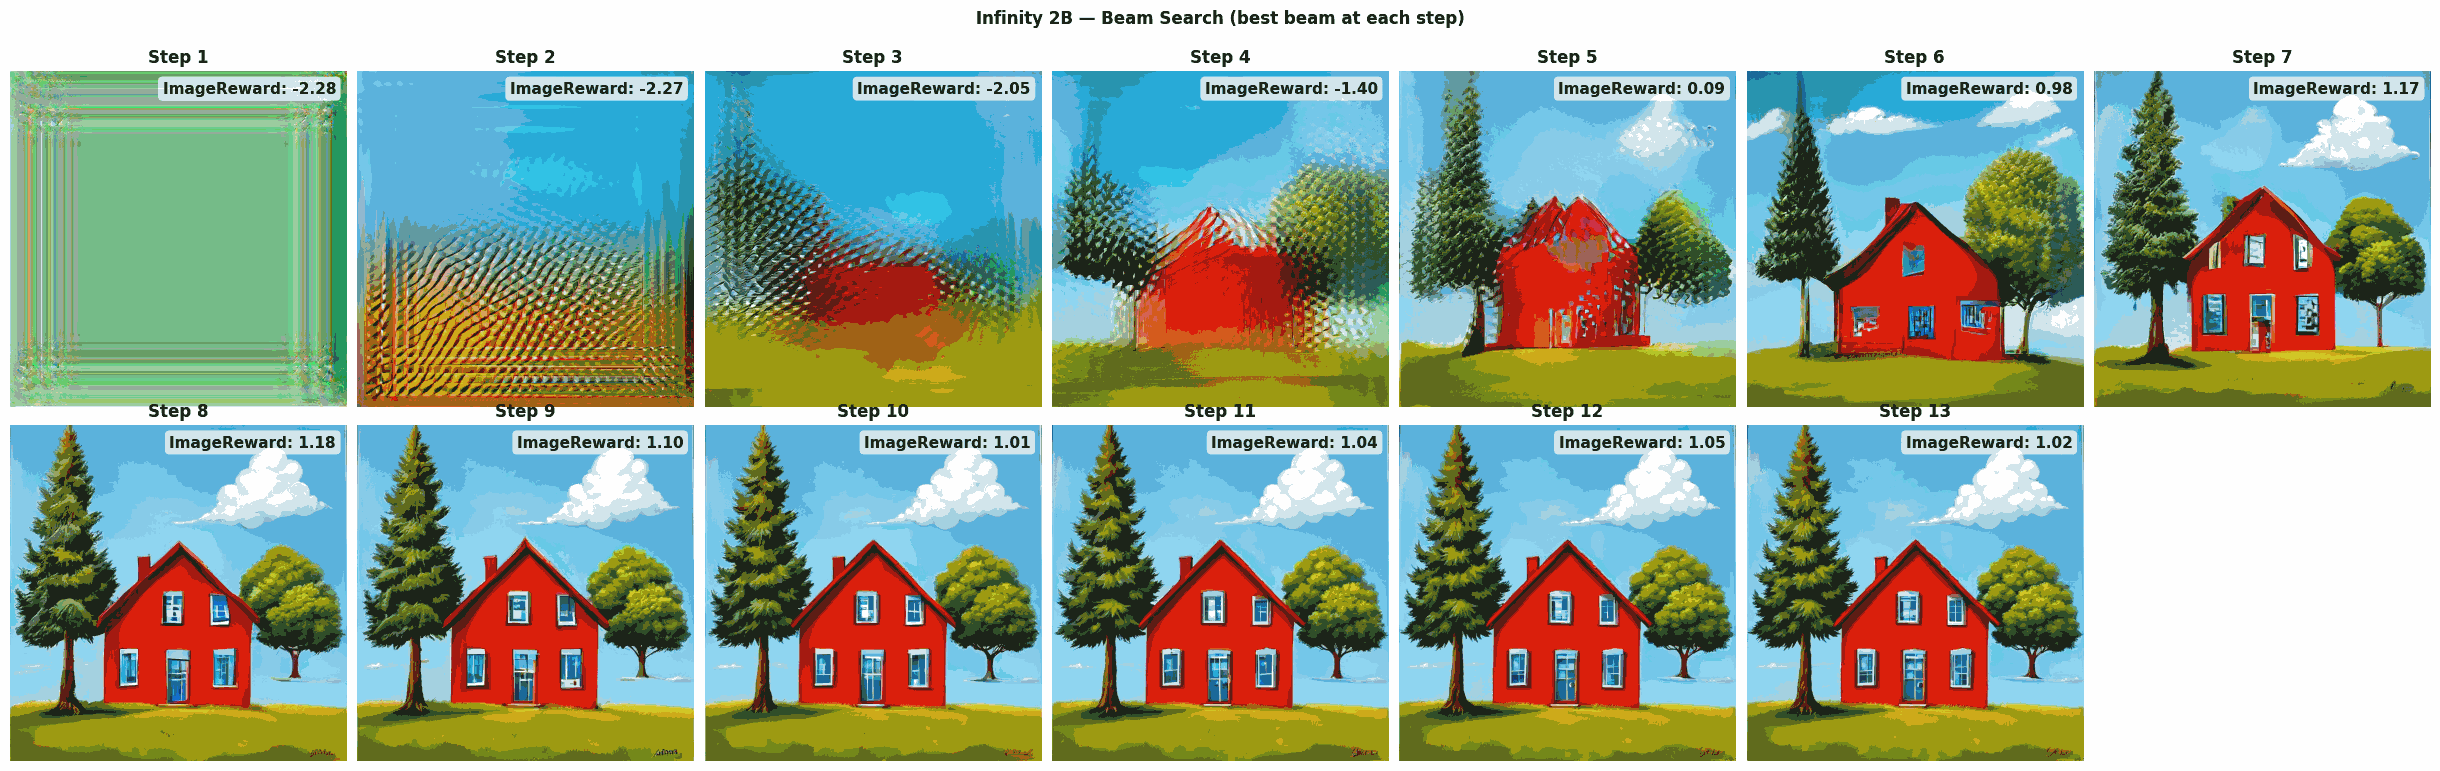

In [12]:
# Takes around 2 min30s to finish on one h100 GPU without flash-attention.
INF_BEAM_CFG = {
    "beam_width": 5,            # beams kept between steps
    "candidates_per_beam": 10,  # candidates branched from each beam per step
    "max_steps": 13,            # one step per scale (13 scales total)
    # "fixed" advances one scale per step, aligning with Infinity's scale boundaries.
    # To skip early low-information scales, replace with token_schedule=[5,6,7,8,9,10,11,12,13].
    "token_schedule": "fixed",
    "replacement": True
}

inf_beam_result = SearchAlgorithmFactory.create(
    "beam", ar_prior=infinity_prior, verifier=verifier, config=INF_BEAM_CFG,
).search(PROMPT, seed=FIXED_SEED)

show_images(
    inf_beam_result.step_images,
    titles=[f"Step {s}" for s in inf_beam_result.metadata["step_schedule"]],
    overlay_labels=list(inf_beam_result.step_scores),
    overlay_prefix="ImageReward",
    main_title="Infinity 2B — Beam Search (best beam at each step)",
    ncols=7,
)

### 2.4 Lookahead Search

Step 8/8: 100%|██████████| 8/8 [19:27<00:00, 145.94s/step, score=1.307, tokens=921]


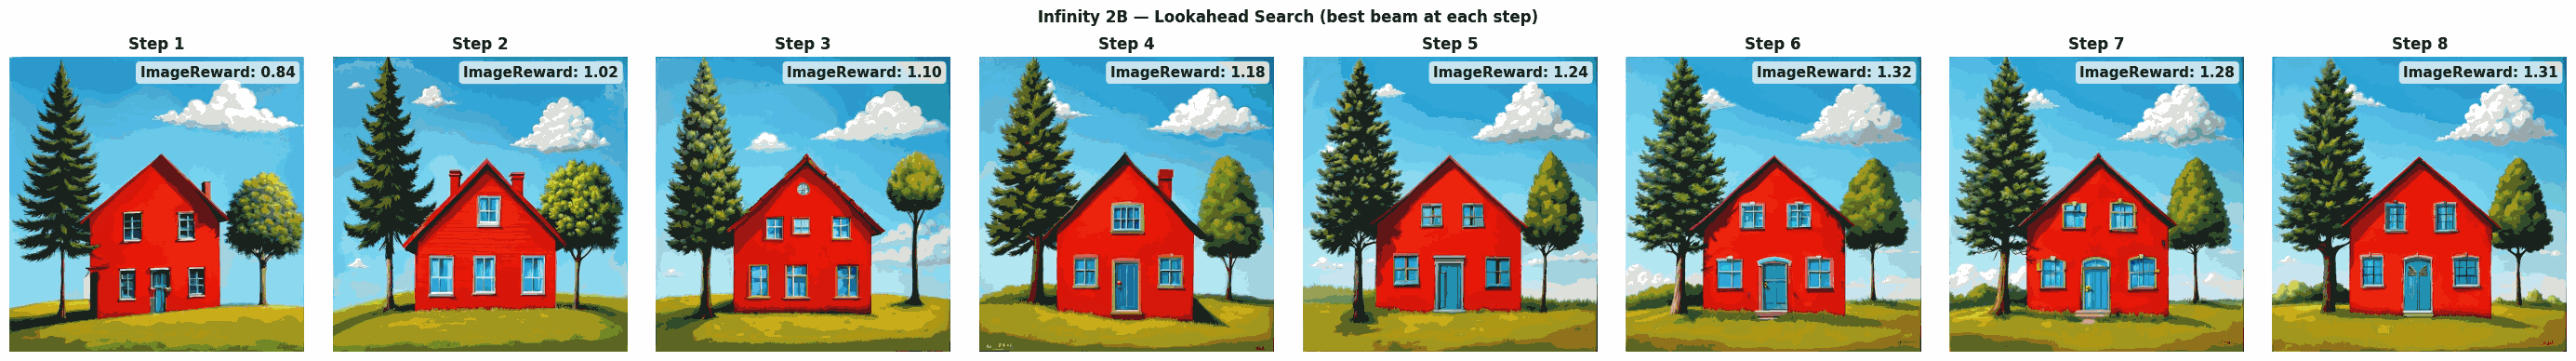

In [13]:
# Takes around 20 min to finish on one h100 GPU without flash-attention.
INF_LA_CFG = {
    "beam_width": 5,                # beams kept between steps
    "candidates_per_beam": 10,       # candidates branched from each beam per step
    "max_steps": 8,                 # search covers scales 1–8
    "token_schedule": "fixed",      # one scale per step
    "lookahead_number": -1,         # extend each candidate to the end of the sequence before scoring
    "max_lookahead_step": 8,        # stop lookahead at step 8 to limit compute
    "complete_after_search": True,  # AR-complete remaining scales (9–13) after search ends
     "replacement": True
}

inf_la_result = SearchAlgorithmFactory.create(
    "lookahead", ar_prior=infinity_prior, verifier=verifier, config=INF_LA_CFG,
).search(PROMPT, seed=FIXED_SEED)

show_images(
    inf_la_result.step_images,
    titles=[f"Step {s}" for s in inf_la_result.metadata["step_schedule"]],
    overlay_labels=list(inf_la_result.step_scores),
    overlay_prefix="ImageReward",
    main_title="Infinity 2B — Lookahead Search (best beam at each step)",
    ncols=8,
)

### 2.5 Summary

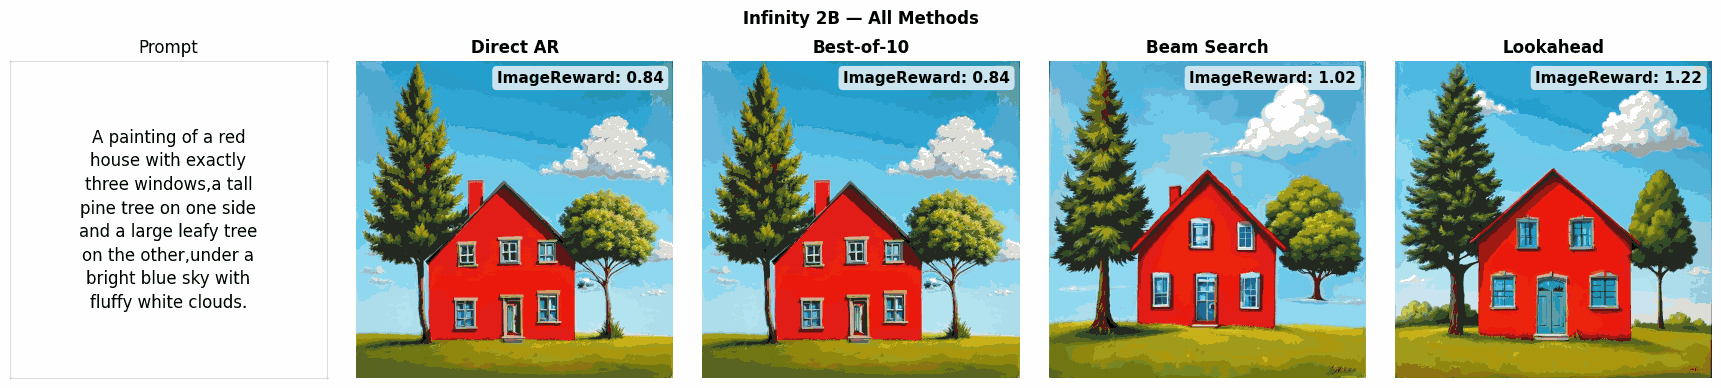

In [14]:
# Summary: compare all four methods on Infinity 2B.
show_images(
    [
        inf_direct_images[0],
        inf_bon_result.images[0],
        inf_beam_result.images[0],
        inf_la_result.images[0],
    ],
    titles=["Direct AR", f"Best-of-{N_SAMPLES}", "Beam Search", "Lookahead" ],
    overlay_labels=[
        float(inf_direct_score),
        float(inf_bon_result.scores[0]),
        float(inf_beam_result.scores[0]),
        float(inf_la_result.scores[0]),
    ],
    overlay_prefix="ImageReward",
    prompt=PROMPT,
    main_title="Infinity 2B — All Methods",
)

In [15]:
# Free GPU memory.
del infinity_prior
torch.cuda.empty_cache()

## Takeaways
- The codebase supports multiple autoregressive models, including FlexTok, Janus, Janus-Pro, and Infinity, within a unified framework. It can be easily extended to new AR models. You can reuse existing search algorithms and verifiers, or design custom search strategies and verification modules tailored to specific models.
- Test-time search can generally improve the original generation quality. However, careful design of the search algorithm and search schedule can further optimize performance.
- Verifiers provide useful guidance but are not always reliable. For example, images with higher verifier scores may not always align with human preferences. Therefore, developing better verifiers is also critical for effective test-time search.